# 03 CNN+BiLSTM+Attention 情感模型训练
在 Colab / AutoDL 上运行，训练自定义情感分类网络。

**使用前**：将整个项目上传到运行环境，或通过 Git clone。

In [1]:
import os
IN_COLAB = 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/identifier'
    os.chdir(PROJECT_ROOT)
    !pip install -q noisereduce librosa soundfile pyyaml
else:
    # 自动查找项目根目录（兼容从任意目录启动 Jupyter）
    for _candidate in [os.path.abspath('..'), os.path.abspath('.'), os.path.expanduser('~/identifier')]:
        if os.path.isfile(os.path.join(_candidate, 'configs', 'config.yaml')):
            PROJECT_ROOT = _candidate
            break
    else:
        raise RuntimeError('找不到项目根目录，请确认 configs/config.yaml 存在')
    os.chdir(PROJECT_ROOT)

print(f'项目根目录: {os.getcwd()}')

项目根目录: /root/identifier


In [2]:
import sys
import time
import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, ConcatDataset, random_split
import matplotlib.pyplot as plt

sys.path.insert(0, PROJECT_ROOT)
from utils.audio_utils import load_config
from preprocessing.feature_extract import EmotionDataset, AudioAugmentation
from models.emotion_cnn_bilstm import EmotionRecognizer

cfg = load_config()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'设备: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name()}')

设备: cuda
GPU: NVIDIA GeForce RTX 4090


## 1. 准备数据

In [3]:
np.random.seed(cfg['training']['seed'])
torch.manual_seed(cfg['training']['seed'])

features_dir = cfg['paths']['features']
augmentation = AudioAugmentation()

datasets_train = []
datasets_plain = []
for subset in ('ravdess', 'casia'):
    d = os.path.join(features_dir, subset)
    if os.path.isdir(os.path.join(d, 'mel')):
        datasets_train.append(EmotionDataset(d, feature_type='mel', transform=augmentation))
        datasets_plain.append(EmotionDataset(d, feature_type='mel', transform=None))

full_train = ConcatDataset(datasets_train)
full_plain = ConcatDataset(datasets_plain)
total = len(full_plain)

train_n = int(total * cfg['training']['train_ratio'])
val_n = int(total * cfg['training']['val_ratio'])
test_n = total - train_n - val_n

gen = torch.Generator().manual_seed(cfg['training']['seed'])
train_idx, val_idx, test_idx = random_split(range(total), [train_n, val_n, test_n], generator=gen)

train_set = torch.utils.data.Subset(full_train, train_idx.indices)
val_set = torch.utils.data.Subset(full_plain, val_idx.indices)
test_set = torch.utils.data.Subset(full_plain, test_idx.indices)

bs = cfg['training']['batch_size']
train_loader = DataLoader(train_set, batch_size=bs, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=bs, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=bs, shuffle=False, num_workers=2, pin_memory=True)

print(f'训练: {train_n}, 验证: {val_n}, 测试: {test_n}')

EmotionDataset: 加载 1440 个样本 (feature_type=mel)
EmotionDataset: 加载 1440 个样本 (feature_type=mel)
训练: 1152, 验证: 144, 测试: 144


## 2. 构建模型

In [4]:
model = EmotionRecognizer(
    num_classes=cfg['emotion']['num_classes'],
    n_mels=cfg['audio']['n_mels'],
    cnn_channels=tuple(cfg['model']['cnn_channels']),
    lstm_hidden=cfg['model']['lstm_hidden'],
    lstm_layers=cfg['model']['lstm_layers'],
    lstm_dropout=cfg['model']['dropout'],
    attn_dim=cfg['model']['attention_dim'],
    cls_hidden=cfg['model']['classifier_hidden'],
    cls_dropout=cfg['model']['classifier_dropout'],
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'模型参数: {total_params:,} (可训练: {trainable_params:,})')
print(model)

模型参数: 1,291,782 (可训练: 1,291,782)
EmotionRecognizer(
  (cnn): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (bilstm): LSTM(2048, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)


## 3. 训练

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=cfg['training']['learning_rate'],
    weight_decay=cfg['training']['weight_decay'],
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5,
)

epochs = cfg['training']['epochs']
patience = cfg['training']['patience']
best_val_loss = float('inf')
best_state = None
wait = 0

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, epochs + 1):
    t0 = time.time()
    
    # 训练
    model.train()
    tr_loss, tr_correct, tr_total = 0, 0, 0
    for feats, labels in train_loader:
        feats, labels = feats.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(feats)
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        tr_loss += loss.item() * feats.size(0)
        tr_correct += (logits.argmax(1) == labels).sum().item()
        tr_total += feats.size(0)
    
    # 验证
    model.eval()
    vl_loss, vl_correct, vl_total = 0, 0, 0
    with torch.no_grad():
        for feats, labels in val_loader:
            feats, labels = feats.to(device), labels.to(device)
            logits = model(feats)
            loss = criterion(logits, labels)
            vl_loss += loss.item() * feats.size(0)
            vl_correct += (logits.argmax(1) == labels).sum().item()
            vl_total += feats.size(0)
    
    tr_loss /= tr_total
    tr_acc = tr_correct / tr_total
    vl_loss /= vl_total
    vl_acc = vl_correct / vl_total
    scheduler.step(vl_loss)
    
    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)
    
    elapsed = time.time() - t0
    print(f'Epoch {epoch:3d}/{epochs} | '
          f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
          f'Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f} | {elapsed:.1f}s')
    
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
        print(f'  -> 最佳模型已保存 (val_loss={vl_loss:.4f})')
    else:
        wait += 1
        if wait >= patience:
            print(f'\n早停: 验证损失连续 {patience} 轮未改善')
            break

# 保存模型
os.makedirs(cfg['paths']['checkpoints'], exist_ok=True)
torch.save(best_state, cfg['paths']['best_emotion_model'])
np.savez(os.path.join(cfg['paths']['checkpoints'], 'emotion_history.npz'), **history)
print(f'\n模型已保存至: {cfg["paths"]["best_emotion_model"]}')

Epoch   1/100 | Train Loss: 1.7716 Acc: 0.2483 | Val Loss: 1.7511 Acc: 0.2500 | 1.7s
  -> 最佳模型已保存 (val_loss=1.7511)
Epoch   2/100 | Train Loss: 1.7468 Acc: 0.2552 | Val Loss: 1.6923 Acc: 0.3264 | 1.0s
  -> 最佳模型已保存 (val_loss=1.6923)
Epoch   3/100 | Train Loss: 1.6703 Acc: 0.2986 | Val Loss: 1.6649 Acc: 0.3056 | 1.1s
  -> 最佳模型已保存 (val_loss=1.6649)
Epoch   4/100 | Train Loss: 1.6308 Acc: 0.3359 | Val Loss: 1.5544 Acc: 0.3333 | 1.0s
  -> 最佳模型已保存 (val_loss=1.5544)
Epoch   5/100 | Train Loss: 1.5704 Acc: 0.3637 | Val Loss: 1.5042 Acc: 0.3819 | 1.0s
  -> 最佳模型已保存 (val_loss=1.5042)
Epoch   6/100 | Train Loss: 1.5641 Acc: 0.3602 | Val Loss: 1.5250 Acc: 0.3681 | 1.0s
Epoch   7/100 | Train Loss: 1.5205 Acc: 0.3802 | Val Loss: 1.3990 Acc: 0.4028 | 1.0s
  -> 最佳模型已保存 (val_loss=1.3990)
Epoch   8/100 | Train Loss: 1.5346 Acc: 0.3854 | Val Loss: 1.4003 Acc: 0.4167 | 1.0s
Epoch   9/100 | Train Loss: 1.4789 Acc: 0.4045 | Val Loss: 1.4469 Acc: 0.3889 | 1.1s
Epoch  10/100 | Train Loss: 1.4491 Acc: 0.4149 | 

## 4. 训练曲线

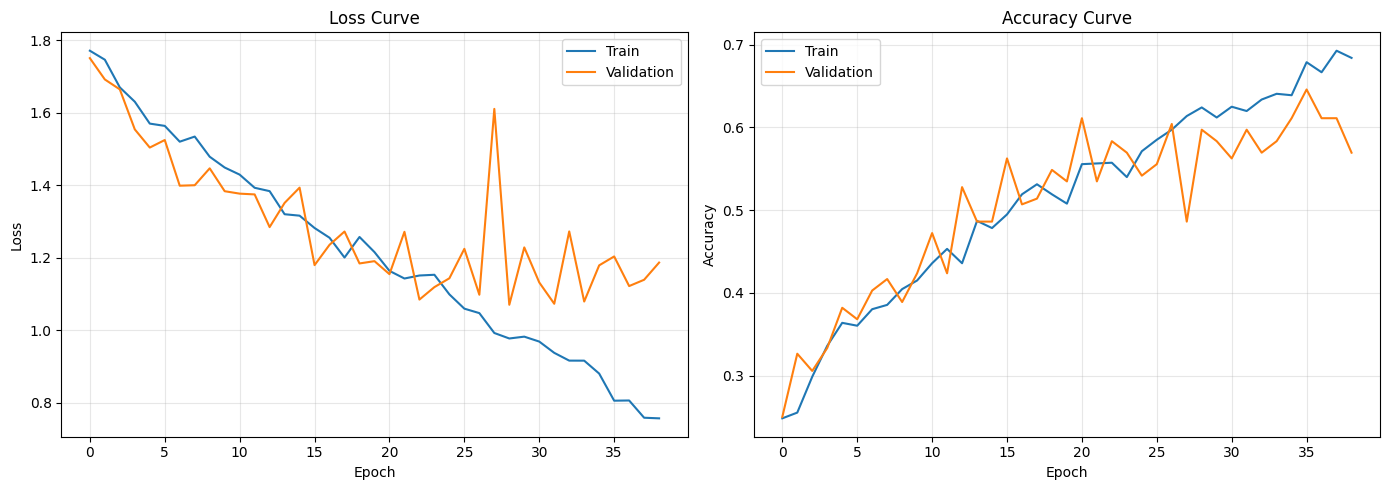

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'], label='Validation')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curve')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['val_acc'], label='Validation')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Curve')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(cfg['paths']['checkpoints'], 'emotion_training_curves.png'), dpi=150)
plt.show()

## 5. 测试集评估

              precision    recall  f1-score   support

       happy       0.17      0.07      0.10        14
       angry       0.87      0.62      0.72        21
         sad       0.67      0.22      0.33        18
     neutral       0.80      0.97      0.88        33
        fear       0.47      0.62      0.54        24
    surprise       0.64      0.85      0.73        34

    accuracy                           0.65       144
   macro avg       0.60      0.56      0.55       144
weighted avg       0.64      0.65      0.62       144



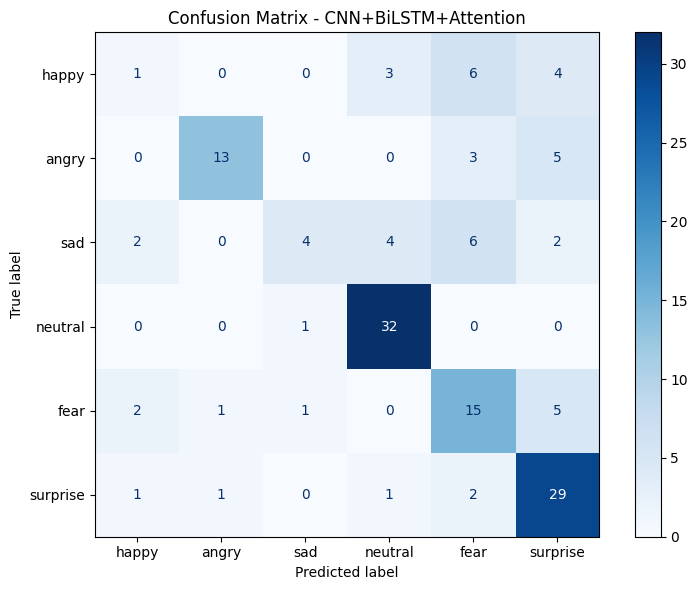

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from utils.audio_utils import EMOTION_LABELS

model.load_state_dict(best_state)
model.eval()

all_preds, all_labels_list = [], []
with torch.no_grad():
    for feats, labels in test_loader:
        feats = feats.to(device)
        preds = model(feats).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels_list.extend(labels.numpy())

print(classification_report(all_labels_list, all_preds, target_names=EMOTION_LABELS))

cm = confusion_matrix(all_labels_list, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=EMOTION_LABELS).plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix - CNN+BiLSTM+Attention')
plt.tight_layout()
plt.savefig(os.path.join(cfg['paths']['checkpoints'], 'confusion_matrix.png'), dpi=150)
plt.show()